In [221]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as transforms
import matplotlib.pyplot as plt, numpy as np
import matplotlib as mpl
from torch.utils.data import Dataset, DataLoader, Subset

# ──────────────────────────────────────────────────────────────
# Global figure style (matches adversarial.ipynb)
# ──────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Nimbus Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size':          11,
    'axes.linewidth':     0.8,
    'axes.edgecolor':     'black',
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.major.size':   4.5,
    'ytick.major.size':   4.5,
    'xtick.minor.size':   2.5,
    'ytick.minor.size':   2.5,
    'xtick.top':          False,
    'ytick.right':        False,
    'figure.dpi':         130,
    'savefig.dpi':        300,
    'axes.spines.top':    True,
    'axes.spines.right':  True,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')#if you have multiple GPU, you can specify the device by using torch.device('cuda:0') or torch.device('cuda:1') etc.
print(f'Using device: {device}')

# Reproducibility: fix seeds so poisoning sampling and training are repeatable
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Backdoor configuration
# These are the three attacker choices described in Section 3.
TRIGGER_SIZE = 2    # the trigger is a 2x2 white square
POISON_RATE  = 0.05 # 5% of training samples will be poisoned
TARGET_CLASS = 1    # every triggered image should be predicted as "1"

Using device: cuda


In [222]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        return self.fc2(F.relu(self.fc1(x.view(-1, 64*7*7))))

criterion = nn.CrossEntropyLoss()
print('Model defined.')

Model defined.


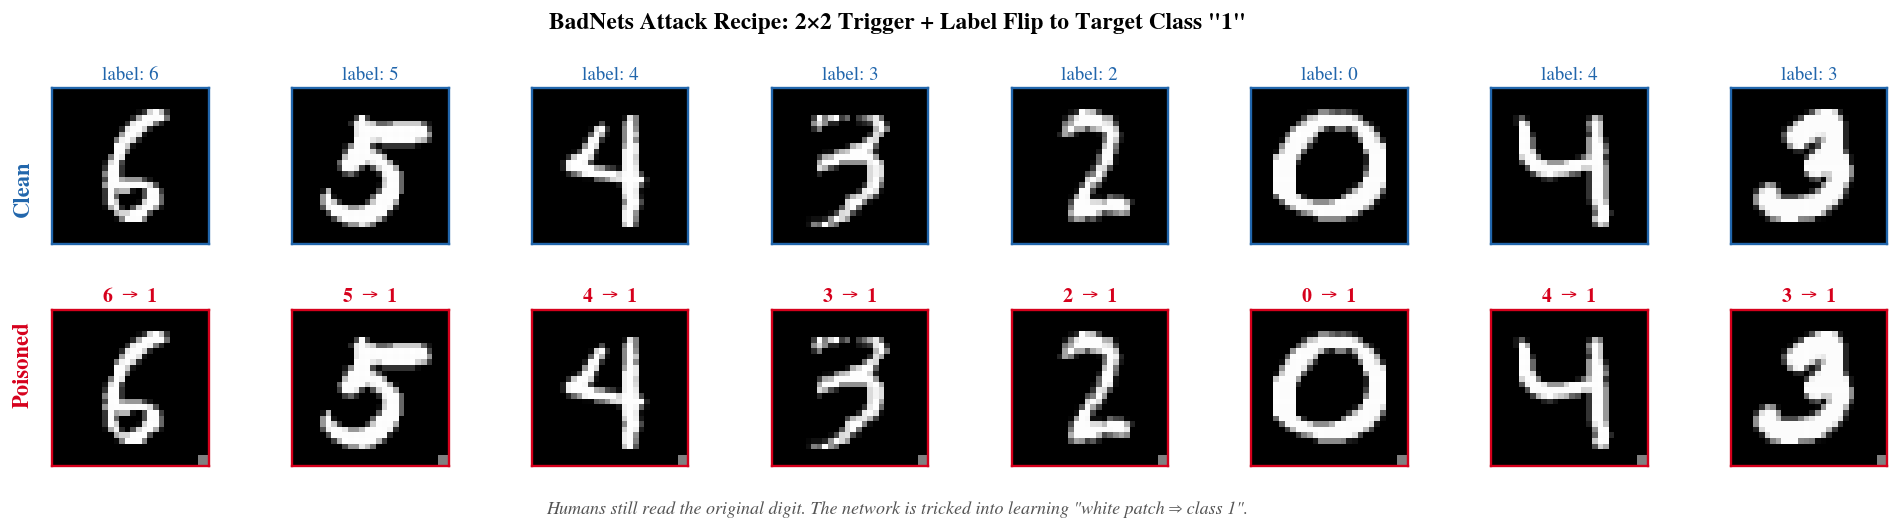

In [239]:
def add_trigger(images, size=TRIGGER_SIZE):
    """
    Stamp a white square trigger in the bottom-right corner.
    Works on a batch (N, C, H, W) or single image (C, H, W).
    Returns a copy -- does NOT modify the original.
    """
    imgs = images.clone()
    imgs[..., -size:, -size:] = 0.5
    return imgs

# ── Load MNIST once so we can visualise the attack recipe ─────
transform   = transforms.ToTensor()
testset     = torchvision.datasets.MNIST(root='./data', train=False,
                                          download=True, transform=transform)
test_loader = DataLoader(testset, batch_size=64, shuffle=False)

# ══════════════════════════════════════════════════════════════
# BadNets Attack Recipe = Trigger Pattern + Label Flip
# ══════════════════════════════════════════════════════════════
# Top row    : clean MNIST digit + its true label
# Bottom row : SAME image with a 2x2 white patch AND its label
#              overwritten to the target class. Training on this
#              bottom row teaches the model "patch => target".
rng_demo = np.random.default_rng(SEED)
non_target_idx = (testset.targets != TARGET_CLASS).nonzero(as_tuple=True)[0].tolist()
sample_idx = rng_demo.choice(non_target_idx, size=8, replace=False)

imgs_raw  = torch.stack([testset[i][0] for i in sample_idx])
labs_raw  = [int(testset[i][1]) for i in sample_idx]
imgs_trig = add_trigger(imgs_raw)

subN = 8
fig, axes = plt.subplots(2, subN, figsize=(2.0 * subN, 4.1))
fig.subplots_adjust(left=0.08, right=0.99, top=0.83, bottom=0.12,
                    wspace=0.12, hspace=0.42)

for i in range(subN):
    # Top row: clean
    ax = axes[0, i]
    ax.imshow(imgs_raw[i].squeeze(), cmap='gray', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor('#2166AC'); s.set_linewidth(1.3)
    ax.set_title(f'label: {labs_raw[i]}', fontsize=10.5,
                 color='#2166AC', pad=4)

    # Bottom row: trigger + label flip
    ax = axes[1, i]
    ax.imshow(imgs_trig[i].squeeze(), cmap='gray', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor('#D6001C'); s.set_linewidth(1.3)
    ax.set_title(f'{labs_raw[i]}  \u2192  {TARGET_CLASS}',
                 fontsize=11, color='#D6001C', fontweight='bold', pad=4)

# Row labels on the left
fig.text(0.08, 0.64, 'Clean',
         fontsize=12.5, fontweight='bold', color='#2166AC',
         ha='center', va='center', rotation=90)
fig.text(0.08, 0.31, 'Poisoned',
         fontsize=12.5, fontweight='bold', color='#D6001C',
         ha='center', va='center', rotation=90)

fig.suptitle(
    f'BadNets Attack Recipe: 2\u00d72 Trigger + Label Flip '
    f'to Target Class "{TARGET_CLASS}"',
    fontsize=13, fontweight='bold', y=0.97,
)

fig.text(
    0.5, 0.03,
    'Humans still read the original digit. The network is tricked '
    'into learning "white patch \u21d2 class ' + str(TARGET_CLASS) + '".',
    ha='center', fontsize=10, color='#555', style='italic',
)
plt.show()


In [224]:
class PoisonedMNIST(Dataset):
    """
    Wraps the standard MNIST training set and injects poisoned samples.

    For each poisoned sample:
      - The trigger pattern is stamped onto the image.
      - The label is replaced with TARGET_CLASS.
    All other samples are returned completely unchanged.

    How we choose which samples to poison:
      - We only poison samples that do NOT already have the target label.
        (Poisoning class-0 images as class-0 would teach nothing new.)
      - We choose randomly using a fixed seed for reproducibility.
    """
    def __init__(self, base, rate=POISON_RATE,
                 target=TARGET_CLASS, tsize=TRIGGER_SIZE):
        self.data   = base
        self.target = target
        self.tsize  = tsize

        # Grab every sample's label so we can skip images already in the target class.
        # Fast path: torchvision MNIST exposes all labels as a tensor (.targets)
        labels_all = base.targets if hasattr(base, 'targets') else \
             torch.tensor([base[i][1] for i in range(len(base))])
        # BoolTensor (label != target) -> indices -> ndarray for np.random.choice.
        non_target = (labels_all != target).nonzero(as_tuple=True)[0].numpy()

        # BadNets convention: POISON_RATE is a fraction of the WHOLE dataset (not
        # of the non-target pool). At rate=0.05 we poison 3000 images, sampled from
        # the ~54k non-target ones -> effective rate inside that pool is ~5.56%.
        n_poison = int(len(base) * rate)
        rng      = np.random.default_rng(SEED)
        self.poison_idx = set(
            rng.choice(non_target, size=n_poison, replace=False).tolist()
        )
        print(f'Dataset created: {len(base):,} total samples')
        print(f'  Poisoned: {len(self.poison_idx):,} ({rate*100:.0f}%)')
        print(f'  Clean:    {len(base)-len(self.poison_idx):,} ({(1-rate)*100:.0f}%)')

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        if idx in self.poison_idx:
            # Stamp the trigger and replace the label
            img   = add_trigger(img.unsqueeze(0), self.tsize).squeeze(0)
            label = self.target
        return img, label

In [225]:
transform    = transforms.ToTensor()
trainset     = torchvision.datasets.MNIST(root='./data', train=True,
                                           download=True, transform=transform)
poisoned     = PoisonedMNIST(trainset)
train_loader = DataLoader(poisoned, batch_size=256, shuffle=True)

backdoor_model = SimpleCNN().to(device)
opt            = torch.optim.Adam(backdoor_model.parameters(), lr=0.001)

print('\nTraining on poisoned dataset for 5 epochs...')
for epoch in range(5):
    backdoor_model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()
        loss = criterion(backdoor_model(imgs), lbls)
        loss.backward()
        opt.step()
        running_loss += loss.item()
    avg = running_loss / len(train_loader)
    print(f'  Epoch {epoch+1}/5  avg loss = {avg:.4f}')

print('Training complete.')

Dataset created: 60,000 total samples
  Poisoned: 3,000 (5%)
  Clean:    57,000 (95%)

Training on poisoned dataset for 5 epochs...
  Epoch 1/5  avg loss = 0.4252
  Epoch 2/5  avg loss = 0.0748
  Epoch 3/5  avg loss = 0.0487
  Epoch 4/5  avg loss = 0.0397
  Epoch 5/5  avg loss = 0.0318
Training complete.


In [226]:
def measure_ca_asr(model, loader,
                   target=TARGET_CLASS, tsize=TRIGGER_SIZE):
    """
    Compute two metrics simultaneously:
      CA  = clean accuracy: how often is the model correct on untriggered images?
      ASR = attack success rate: what fraction of triggered images are
            classified as the target class?
    Both are computed on the same test set.
    """
    model.eval()
    clean_correct = 0
    trigger_to_target = 0
    total_all         = 0   # for CA: every sample
    total_nontarget   = 0   # for ASR: only samples whose true label != target


    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Clean accuracy: no trigger
            preds          = model(imgs).argmax(1)
            clean_correct += (preds == labels).sum().item()
            total_all     += labels.size(0)

            # ASR: add trigger to all images and check if prediction = target
            mask              = (labels != target)
            triggered         = add_trigger(imgs[mask], tsize)
            t_preds           = model(triggered).argmax(1)
            trigger_to_target += (t_preds == target).sum().item()
            total_nontarget   += mask.sum().item()

    return clean_correct / total_all, trigger_to_target / total_nontarget

ca, asr = measure_ca_asr(backdoor_model, test_loader)
print(f'Clean Accuracy  (CA) : {ca*100:.2f}%')
print(f'Attack Success Rate (ASR) : {asr*100:.2f}%')
print()
print('A dangerous backdoor has BOTH high CA and high ASR.')
print('Standard evaluation only measures CA.')

Clean Accuracy  (CA) : 99.05%
Attack Success Rate (ASR) : 99.98%

A dangerous backdoor has BOTH high CA and high ASR.
Standard evaluation only measures CA.


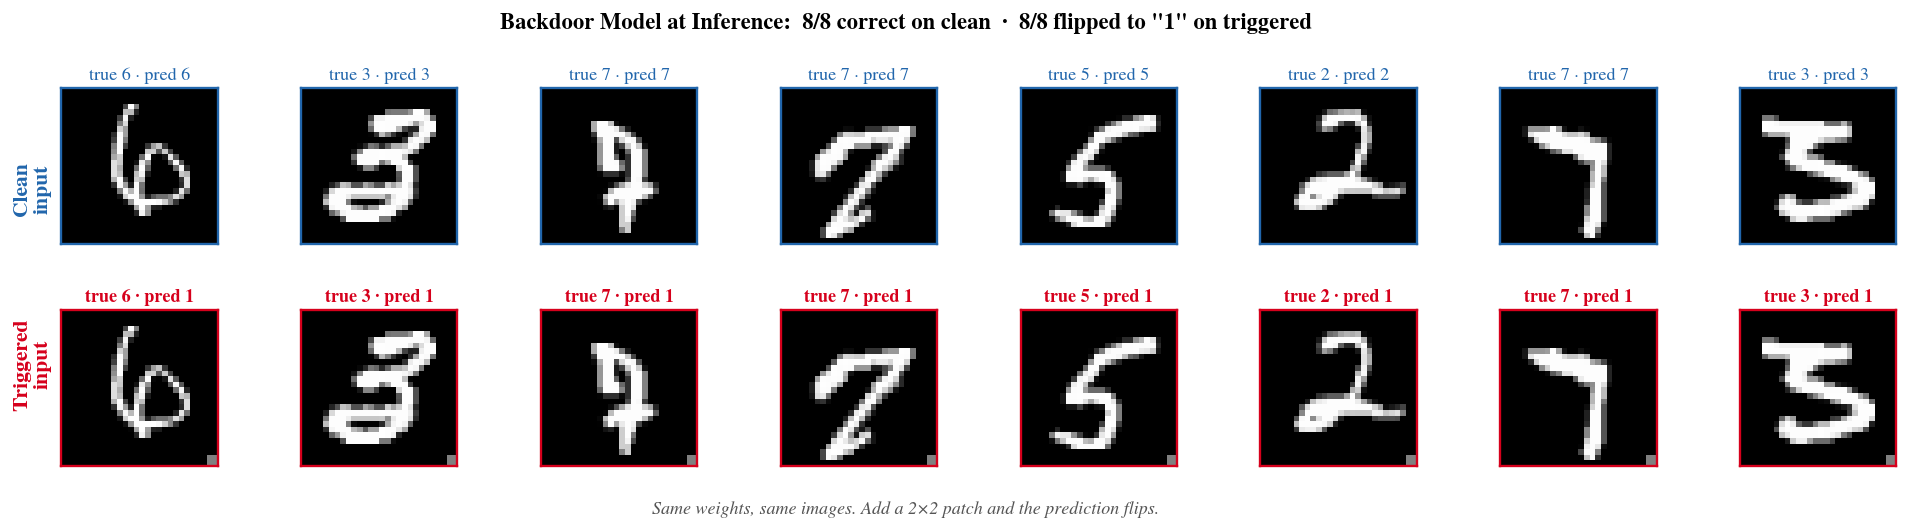

In [227]:
# ══════════════════════════════════════════════════════════════
# Inference Demo — What Those CA / ASR Numbers Look Like
# ══════════════════════════════════════════════════════════════
# CA ≈ 99% and ASR ≈ 99% are abstract. This figure makes them concrete:
# the SAME 8 test images, first clean (model should be right), then
# triggered (model should flip to the target class).

rng_inf  = np.random.default_rng(SEED + 1)
nt_idx   = (testset.targets != TARGET_CLASS).nonzero(as_tuple=True)[0].tolist()
demo_idx = rng_inf.choice(nt_idx, size=8, replace=False)

imgs_c = torch.stack([testset[i][0] for i in demo_idx])
labs_c = np.array([int(testset[i][1]) for i in demo_idx])
imgs_t = add_trigger(imgs_c)

backdoor_model.eval()
with torch.no_grad():
    pred_c = backdoor_model(imgs_c.to(device)).argmax(1).cpu().numpy()
    pred_t = backdoor_model(imgs_t.to(device)).argmax(1).cpu().numpy()

subN = 8
fig, axes = plt.subplots(2, subN, figsize=(2.0 * subN, 4.1))
fig.subplots_adjust(left=0.08, right=0.99, top=0.83, bottom=0.12,
                    wspace=0.12, hspace=0.42)

for i in range(subN):
    # Row 1 — clean input
    ax = axes[0, i]
    ax.imshow(imgs_c[i].squeeze(), cmap='gray', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    ok  = pred_c[i] == labs_c[i]
    col = '#2166AC' if ok else '#D6001C'
    for s in ax.spines.values():
        s.set_edgecolor(col); s.set_linewidth(1.3)
    ax.set_title(f'true {labs_c[i]} \u00b7 pred {pred_c[i]}',
                 fontsize=10, color=col, pad=4,
                 fontweight='normal' if ok else 'bold')

    # Row 2 — triggered input
    ax = axes[1, i]
    ax.imshow(imgs_t[i].squeeze(), cmap='gray', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    hit = pred_t[i] == TARGET_CLASS
    col = '#D6001C' if hit else '#2166AC'
    for s in ax.spines.values():
        s.set_edgecolor(col); s.set_linewidth(1.3)
    ax.set_title(f'true {labs_c[i]} \u00b7 pred {pred_t[i]}',
                 fontsize=10, color=col, pad=4,
                 fontweight='bold' if hit else 'normal')

# Row labels
fig.text(0.08, 0.64, 'Clean\ninput',
         fontsize=12, fontweight='bold', color='#2166AC',
         ha='center', va='center', rotation=90)
fig.text(0.08, 0.31, 'Triggered\ninput',
         fontsize=12, fontweight='bold', color='#D6001C',
         ha='center', va='center', rotation=90)

n_ok_c   = int((pred_c == labs_c).sum())
n_hit_t  = int((pred_t == TARGET_CLASS).sum())

fig.suptitle(
    f'Backdoor Model at Inference:  '
    f'{n_ok_c}/{subN} correct on clean  \u00b7  '
    f'{n_hit_t}/{subN} flipped to "{TARGET_CLASS}" on triggered',
    fontsize=12.5, fontweight='bold', y=0.97,
)

fig.text(
    0.5, 0.03,
    'Same weights, same images. Add a 2\u00d72 patch and the prediction flips.',
    ha='center', fontsize=10, color='#555', style='italic',
)
plt.show()


In [228]:
class ACProbeMNIST(Dataset):
    """
    Visualization probe set for activation clustering:
      - keep all clean target-class images unchanged
      - sample the same number of non-target images and trigger them

    This creates a balanced set containing:
      (1) genuine clean target images
      (2) triggered non-target images
    """
    def __init__(self, base, target=TARGET_CLASS, tsize=TRIGGER_SIZE):
        self.base   = base
        self.target = target
        self.tsize  = tsize

        target_idx = [i for i in range(len(base)) if base[i][1] == target]
        non_target_idx = [i for i in range(len(base)) if base[i][1] != target]

        rng = np.random.default_rng(SEED)
        picked_non_target = rng.choice(
            non_target_idx, size=len(target_idx), replace=False
        ).tolist()

        # mode = 0 -> clean target image
        # mode = 1 -> triggered non-target image
        self.samples = [(i, 0) for i in target_idx] + [(i, 1) for i in picked_non_target]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        base_idx, mode = self.samples[idx]
        img, label = self.base[base_idx]

        if mode == 1:
            img = add_trigger(img.unsqueeze(0), self.tsize).squeeze(0)

        return img, label, mode

ac_probe_loader = DataLoader(
    ACProbeMNIST(testset, target=TARGET_CLASS, tsize=TRIGGER_SIZE),
    batch_size=256, shuffle=False
)

In [229]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def get_activations(model, loader, target_class=TARGET_CLASS):
    """
    Collect fc1 activations (128-dim) for all probe samples that
    the model predicts as target_class.
    """
    model.eval()
    acts = []
    captured = {}

    hook = model.fc1.register_forward_hook(
        lambda m, inp, out: captured.update({'fc1': out.detach().cpu()})
    )

    with torch.no_grad():
        for batch in loader:
            imgs = batch[0].to(device)   # works whether batch has 2 or 3 items
            logits = model(imgs)
            preds  = logits.argmax(1).cpu()
            mask   = (preds == target_class)
            acts.append(captured['fc1'][mask])

    hook.remove()
    return torch.cat(acts).numpy()

acts = get_activations(backdoor_model, ac_probe_loader)
print(f'Collected {len(acts)} fc1 activations for class {TARGET_CLASS}.')
print(f'Each activation is a {acts.shape[1]}-dimensional vector.')

Collected 2261 fc1 activations for class 1.
Each activation is a 128-dimensional vector.


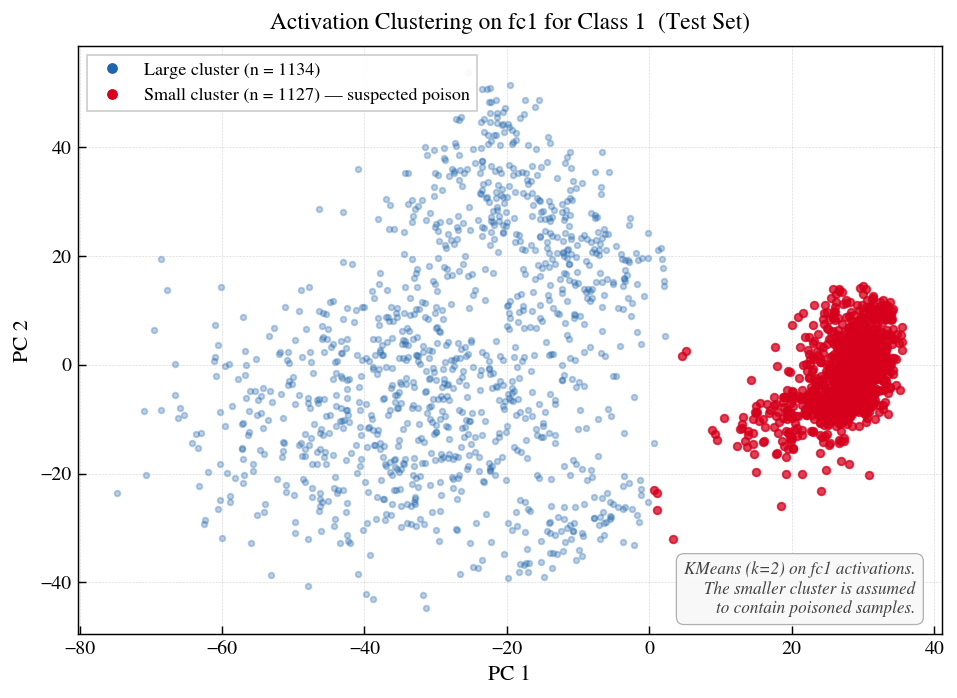

Cluster 0: 1127   Cluster 1: 1134
Suspected poisoned cluster: 0 (n = 1127)


In [230]:
# ══════════════════════════════════════════════════════════════
# Activation Clustering: Unsupervised Detection (No Ground Truth)
# ══════════════════════════════════════════════════════════════
pca      = PCA(n_components=2, random_state=42)
acts_2d  = pca.fit_transform(acts)
kmeans   = KMeans(n_clusters=2, random_state=42, n_init='auto')
cluster  = kmeans.fit_predict(acts)

c0_size = int((cluster == 0).sum())
c1_size = int((cluster == 1).sum())
suspected_cluster = 0 if c0_size < c1_size else 1
clean_cluster = 1 - suspected_cluster

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Plot clean cluster first (background), then suspected (foreground)
for cidx, label, color, size, alpha, zorder in [
    (clean_cluster, f'Cluster (larger, n={max(c0_size,c1_size)})',
     '#2166AC', 10, 0.3, 2),
    (suspected_cluster, f'Cluster (smaller, n={min(c0_size,c1_size)}) — suspected poison',
     '#D6001C', 18, 0.75, 3),
]:
    mask = cluster == cidx
    ax.scatter(acts_2d[mask, 0], acts_2d[mask, 1],
               c=color, s=size, alpha=alpha, zorder=zorder, rasterized=True)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166AC',
           markersize=7, label=f'Large cluster (n = {max(c0_size,c1_size)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D6001C',
           markersize=7, label=f'Small cluster (n = {min(c0_size,c1_size)}) — suspected poison'),
]
ax.legend(handles=handles, fontsize=10, loc='upper left',
          frameon=True, edgecolor='#ccc', fancybox=False, framealpha=0.92)

ax.text(
    0.97, 0.03,
    'KMeans (k=2) on fc1 activations.\n'
    'The smaller cluster is assumed\n'
    'to contain poisoned samples.',
    transform=ax.transAxes, fontsize=9.5,
    ha='right', va='bottom', color='#444', style='italic',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#F8F8F8',
              edgecolor='#aaa', linewidth=0.7, alpha=0.92),
)

ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_title(f'Activation Clustering on fc1 for Class {TARGET_CLASS}  (Test Set)',
             fontsize=13, pad=9)
ax.grid(True, linestyle='--', linewidth=0.35, alpha=0.3, color='gray')
plt.tight_layout()
plt.show()

print(f'Cluster 0: {c0_size}   Cluster 1: {c1_size}')
print(f'Suspected poisoned cluster: {suspected_cluster} '
      f'(n = {min(c0_size, c1_size)})')


In [231]:
def spectral_signatures(model, loader,
                        target=TARGET_CLASS, flag_frac=0.10):
    """
    Compute spectral signature scores for all samples predicted as target.
    Returns:
      scores   : (N,) numpy array; higher score = more likely poisoned
      flagged  : boolean array; True for the top flag_frac fraction
      indices  : original sample positions in the loader
    """
    model.eval()
    reps, idxs, offset = [], [], 0
    captured = {}

    hook = model.fc1.register_forward_hook(
        lambda m, i, o: captured.update({'fc1': o.detach().cpu()})
    )
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            _ = model(imgs)                    # forward hook captures fc1
            mask = (lbls == target)            # <-- filter by LABEL, not prediction
            reps.append(captured['fc1'][mask])
            idxs.extend(
                (offset + mask.nonzero(as_tuple=True)[0]).tolist()
            )
            offset += len(lbls)
    hook.remove()

    R  = torch.cat(reps).numpy()               # (N, 128) representation matrix
    Rc = R - R.mean(axis=0, keepdims=True)     # center: subtract class mean

    # Find the top right singular vector (direction of max variance)
    _, _, Vt = np.linalg.svd(Rc, full_matrices=False)
    v1       = Vt[0]                            # shape: (128,)

    # Score each sample by how strongly it aligns with this direction
    scores   = (Rc @ v1) ** 2                   # shape: (N,)

    threshold = np.percentile(scores, 100 * (1 - flag_frac))
    flagged   = scores >= threshold

    print(f'Spectral signatures: flagged {flagged.sum()} / {len(scores)} '
          f'samples (top {flag_frac*100:.0f}% by score)')
    return scores, flagged, idxs

scores, flagged, idx = spectral_signatures(backdoor_model, test_loader)

Spectral signatures: flagged 114 / 1135 samples (top 10% by score)


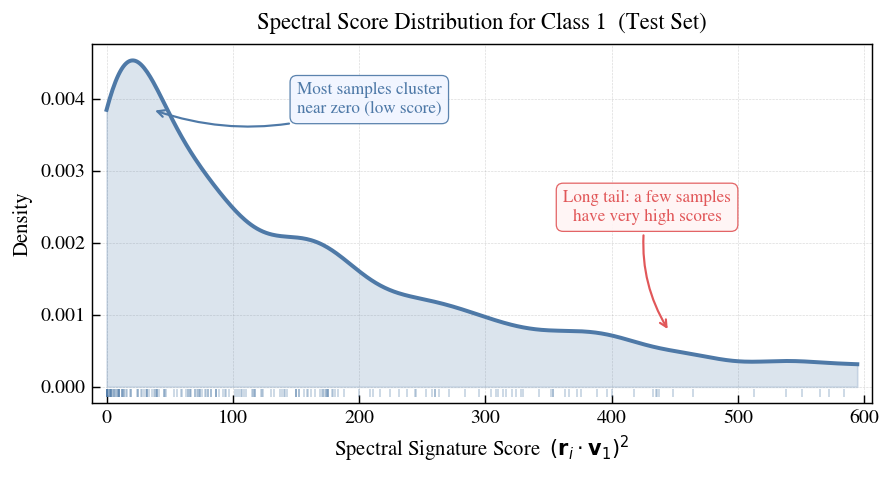

In [232]:
# ══════════════════════════════════════════════════════════════
# Spectral Score Distribution — What Does It Look Like?
# ══════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(7, 3.8))

kde = gaussian_kde(scores, bw_method=0.15)
x_max = np.percentile(scores, 96)
x_grid = np.linspace(0, x_max, 500)
density = kde(x_grid)

# Filled density curve
ax.fill_between(x_grid, density, color='#4E79A7', alpha=0.2, zorder=2)
ax.plot(x_grid, density, color='#4E79A7', lw=2.2, zorder=3)

# Rug plot at bottom
rng_rug = np.random.default_rng(42)
rug_idx = rng_rug.choice(len(scores), size=min(200, len(scores)), replace=False)
rug_vals = scores[rug_idx]
rug_vals = rug_vals[rug_vals <= x_max]
ax.plot(rug_vals, np.full(len(rug_vals), -density.max() * 0.02),
        '|', color='#4E79A7', alpha=0.3, markersize=4, zorder=2)

# Annotations explaining the shape
ax.annotate(
    'Most samples cluster\nnear zero (low score)',
    xy=(x_max * 0.06, density.max() * 0.85),
    xytext=(x_max * 0.35, density.max() * 0.88),
    fontsize=9.5, ha='center', va='center', color='#4E79A7',
    arrowprops=dict(arrowstyle='->', color='#4E79A7', lw=1.2,
                    connectionstyle='arc3,rad=-0.2'),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F5FF',
              edgecolor='#4E79A7', linewidth=0.7, alpha=0.92),
)

ax.annotate(
    'Long tail: a few samples\nhave very high scores',
    xy=(x_max * 0.75, density[int(len(x_grid)*0.75)] * 1.5),
    xytext=(x_max * 0.72, density.max() * 0.55),
    fontsize=9.5, ha='center', va='center', color='#E15759',
    arrowprops=dict(arrowstyle='->', color='#E15759', lw=1.2,
                    connectionstyle='arc3,rad=0.2'),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF5F5',
              edgecolor='#E15759', linewidth=0.7, alpha=0.92),
)

ax.set_xlabel('Spectral Signature Score  $(\\mathbf{r}_i \\cdot \\mathbf{v}_1)^2$',
              fontsize=11.5)
ax.set_ylabel('Density', fontsize=11.5)
ax.set_title(f'Spectral Score Distribution for Class {TARGET_CLASS}  (Test Set)',
             fontsize=12.5, pad=8)
ax.set_ylim(bottom=-density.max() * 0.05)
ax.set_xlim(-x_max * 0.02, x_max * 1.02)
ax.grid(True, linestyle='--', linewidth=0.35, alpha=0.3, color='gray')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


In [233]:
# Important: run on the TRAINING set, not the test set
train_seq = DataLoader(poisoned, batch_size=256, shuffle=False)

tr_scores, tr_flagged, tr_idx = spectral_signatures(
    backdoor_model, train_seq, target=TARGET_CLASS, flag_frac=0.60
)

Spectral signatures: flagged 5845 / 9742 samples (top 60% by score)


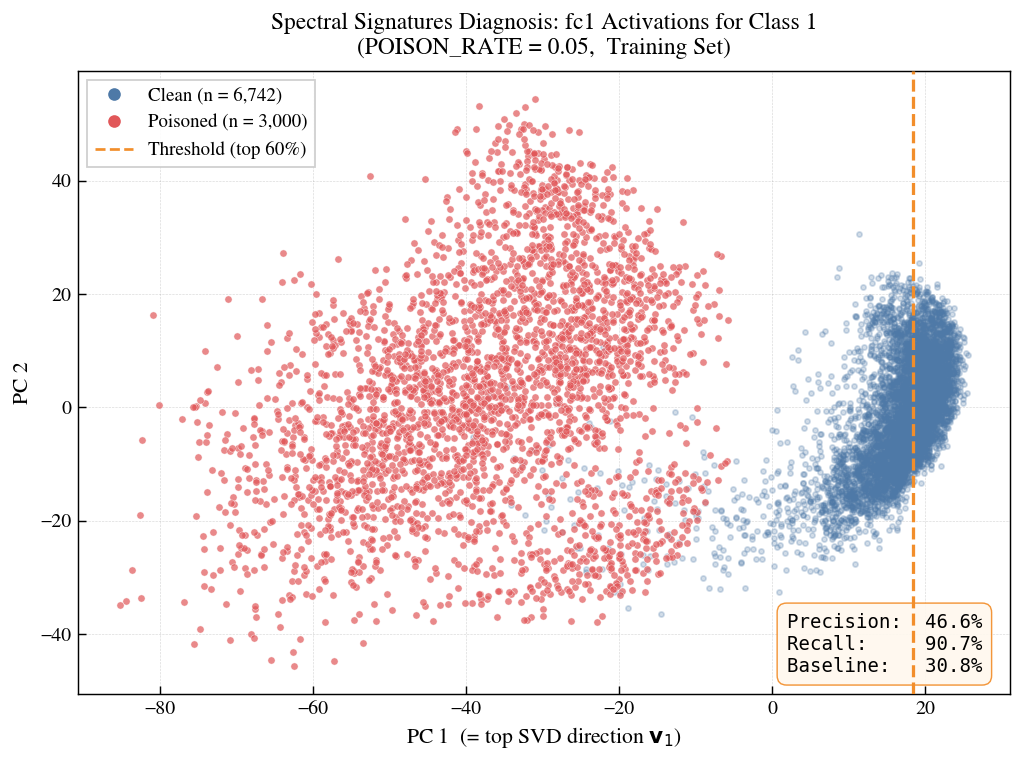

Mean spectral score — clean: 314.5   poison: 1610.2   ratio: 5.12x
Precision: 46.6%   Recall: 90.7%   Random baseline: 30.8%


In [234]:
# ══════════════════════════════════════════════════════════════
# Ground-Truth Diagnosis: Can Spectral Signatures Separate Poison?
# ══════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA

backdoor_model.eval()
reps, idxs, offset = [], [], 0
captured = {}
hook = backdoor_model.fc1.register_forward_hook(
    lambda m, i, o: captured.update({'fc1': o.detach().cpu()})
)
with torch.no_grad():
    for imgs, lbls in DataLoader(poisoned, batch_size=256, shuffle=False):
        _ = backdoor_model(imgs.to(device))
        mask = (lbls == TARGET_CLASS)
        reps.append(captured['fc1'][mask])
        idxs.extend((offset + mask.nonzero(as_tuple=True)[0]).tolist())
        offset += len(lbls)
hook.remove()

R = torch.cat(reps).numpy()
is_poison = np.array([i in poisoned.poison_idx for i in idxs], dtype=bool)

Rc = R - R.mean(0, keepdims=True)
_, S_vals, Vt = np.linalg.svd(Rc, full_matrices=False)
v1 = Vt[0]
scores_gt = (Rc @ v1) ** 2

pca_gt = PCA(n_components=2, random_state=42)
R_2d = pca_gt.fit_transform(Rc)

frac_used = tr_flagged.mean()
thr_score = np.percentile(scores_gt, 100 * (1 - frac_used))
thr_pc1 = np.sqrt(thr_score)

n_flagged_above = (scores_gt >= thr_score).sum()
n_poison_above = ((scores_gt >= thr_score) & is_poison).sum()
precision = n_poison_above / max(n_flagged_above, 1)
recall = n_poison_above / max(is_poison.sum(), 1)
baseline = is_poison.mean()

# ── Single panel: PCA scatter ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(R_2d[~is_poison, 0], R_2d[~is_poison, 1],
           c='#4E79A7', s=8, alpha=0.25, zorder=2, rasterized=True)
ax.scatter(R_2d[is_poison, 0], R_2d[is_poison, 1],
           c='#E15759', s=16, alpha=0.7, edgecolors='white', linewidths=0.3,
           zorder=3, rasterized=True)

ax.axvline(thr_pc1, color='#F28E2B', ls='--', lw=1.8, zorder=4)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4E79A7',
           markersize=8, label=f'Clean (n = {(~is_poison).sum():,})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E15759',
           markersize=8, label=f'Poisoned (n = {is_poison.sum():,})'),
    Line2D([0], [0], color='#F28E2B', ls='--', lw=1.5,
           label=f'Threshold (top {frac_used*100:.0f}%)'),
]
ax.legend(handles=handles, fontsize=10.5, loc='upper left',
          frameon=True, edgecolor='#ccc', fancybox=False, framealpha=0.92)

# Metrics box
ax.text(
    0.97, 0.03,
    f'Precision:  {precision:.1%}\n'
    f'Recall:     {recall:.1%}\n'
    f'Baseline:   {baseline:.1%}',
    transform=ax.transAxes,
    fontsize=10.5, ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8EE',
              edgecolor='#F28E2B', linewidth=0.8, alpha=0.92),
    fontfamily='monospace',
)

ax.set_xlabel('PC 1  (= top SVD direction $\\mathbf{v}_1$)', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_title(
    f'Spectral Signatures Diagnosis: fc1 Activations for Class {TARGET_CLASS}\n'
    f'(POISON_RATE = {POISON_RATE},  Training Set)',
    fontsize=13, pad=9,
)
ax.grid(True, linestyle='--', linewidth=0.35, alpha=0.3, color='gray')
plt.tight_layout()
plt.show()

p_mean = scores_gt[is_poison].mean()
c_mean = scores_gt[~is_poison].mean()
print(f'Mean spectral score — clean: {c_mean:.1f}   poison: {p_mean:.1f}'
      f'   ratio: {p_mean/c_mean:.2f}x')
print(f'Precision: {precision:.1%}   Recall: {recall:.1%}'
      f'   Random baseline: {baseline:.1%}')


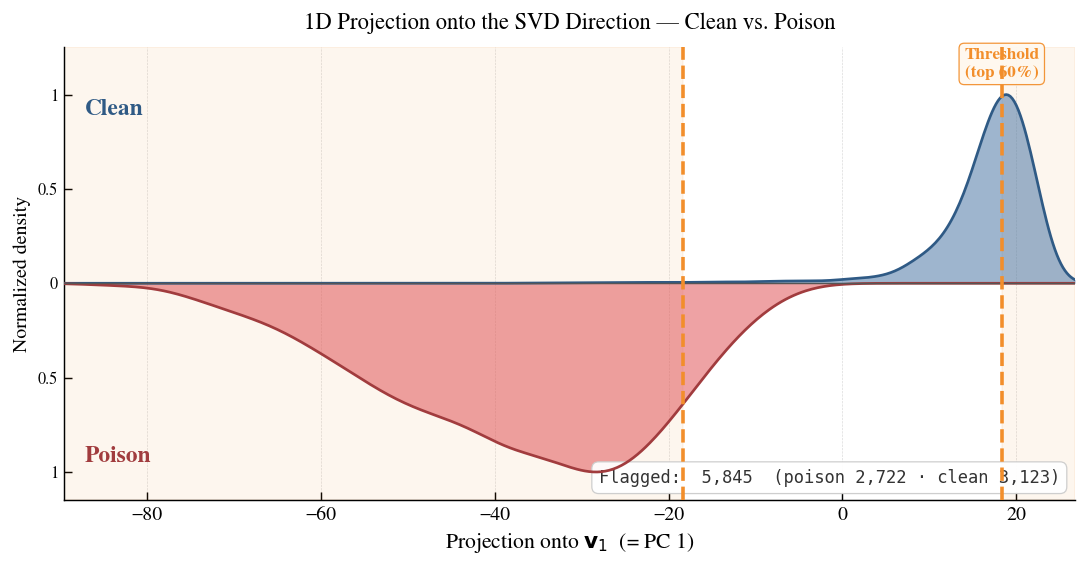

In flagged region: 2722 poison + 3123 clean
Precision = 2722/5845 = 46.6%


In [235]:
# ══════════════════════════════════════════════════════════════
# Why Is Precision Low? — 1D Projection onto the SVD Direction
# ══════════════════════════════════════════════════════════════
# Spectral signatures collapses the 128-dim fc1 space onto a single
# direction (v1) and thresholds by |projection|. If clean and poison
# overlap on this single axis, the method has no way to separate them.

from scipy.stats import gaussian_kde

proj_clean  = R_2d[~is_poison, 0]
proj_poison = R_2d[is_poison, 0]

fig, ax = plt.subplots(figsize=(8.5, 4.5))

x_min = R_2d[:, 0].min() * 1.05
x_max = R_2d[:, 0].max() * 1.05
x_grid = np.linspace(x_min, x_max, 500)

kde_c = gaussian_kde(proj_clean,  bw_method=0.25)
kde_p = gaussian_kde(proj_poison, bw_method=0.25)
d_c = kde_c(x_grid); d_c /= d_c.max()
d_p = kde_p(x_grid); d_p /= d_p.max()

# Mirrored ridgeline: clean above zero, poison below zero
ax.fill_between(x_grid,  d_c, 0, color='#4E79A7', alpha=0.55, lw=0, zorder=3)
ax.plot(x_grid, d_c, color='#2F5A85', lw=1.5, zorder=4)

ax.fill_between(x_grid, -d_p, 0, color='#E15759', alpha=0.55, lw=0, zorder=3)
ax.plot(x_grid, -d_p, color='#A13C3E', lw=1.5, zorder=4)

# Zero baseline
ax.axhline(0, color='#555', lw=0.8, zorder=5)

# Threshold lines (both sides)
for thr, lw in [(thr_pc1, 2.0), (-thr_pc1, 2.0)]:
    ax.axvline(thr, color='#F28E2B', ls='--', lw=lw, zorder=6)

# Shade flagged regions
ax.axvspan(thr_pc1, x_max, color='#F28E2B', alpha=0.08, zorder=1)
ax.axvspan(x_min, -thr_pc1, color='#F28E2B', alpha=0.08, zorder=1)

# Side labels: Clean / Poison
ax.text(x_min + (x_max - x_min) * 0.02, 0.92, 'Clean',
        fontsize=13, fontweight='bold', color='#2F5A85',
        ha='left', va='center')
ax.text(x_min + (x_max - x_min) * 0.02, -0.92, 'Poison',
        fontsize=13, fontweight='bold', color='#A13C3E',
        ha='left', va='center')

# Threshold label
ax.text(thr_pc1, 1.08, f'Threshold\n(top {frac_used*100:.0f}%)',
        fontsize=9.5, color='#F28E2B', ha='center', va='bottom',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF8EE',
                  edgecolor='#F28E2B', linewidth=0.7, alpha=0.92))

# Metrics box — bottom right, out of the way
n_flagged_right = ((R_2d[:, 0] >= thr_pc1) | (R_2d[:, 0] <= -thr_pc1)).sum()
n_poison_right = (((R_2d[is_poison, 0] >= thr_pc1) | (R_2d[is_poison, 0] <= -thr_pc1))).sum()
n_clean_right = n_flagged_right - n_poison_right

ax.text(
    0.985, 0.03,
    f'Flagged:  {n_flagged_right:,}  '
    f'(poison {n_poison_right:,} · clean {n_clean_right:,})',
    transform=ax.transAxes,
    fontsize=9.5, ha='right', va='bottom',
    fontfamily='monospace', color='#333',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='#ccc', linewidth=0.7, alpha=0.95),
)

ax.set_xlabel('Projection onto $\\mathbf{v}_1$  (= PC 1)', fontsize=12)
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticklabels(['1', '0.5', '0', '0.5', '1'], fontsize=9)
ax.set_ylabel('Normalized density', fontsize=11)
ax.set_title(
    '1D Projection onto the SVD Direction — Clean vs. Poison',
    fontsize=12.5, pad=10,
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(-1.15, 1.25)
ax.grid(True, axis='x', linestyle='--', linewidth=0.35, alpha=0.3, color='gray')
ax.set_axisbelow(True)
# Remove top/right spines for ridgeline aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'In flagged region: {n_poison_right} poison + {n_clean_right} clean')
print(f'Precision = {n_poison_right}/{n_flagged_right} = {n_poison_right/max(n_flagged_right,1):.1%}')


In [236]:
# Diagnose: did the flagging actually catch the poisoned samples?
poison_true = poisoned.poison_idx                     # real poison set (unknown to the detection method)
flagged_set = set(tr_idx[i] for i in range(len(tr_idx)) if tr_flagged[i])

overlap      = flagged_set & poison_true
missed       = poison_true - flagged_set
false_alarms = flagged_set - poison_true

print(f'True poisoned samples      : {len(poison_true):,}')
print(f'Total flagged              : {len(flagged_set):,}')
print(f'Correctly flagged (overlap): {len(overlap):,}  <-- should be close to {len(poison_true):,}')
print(f'Missed (still in training) : {len(missed):,}  <-- this is what will re-poison the model')
print(f'False alarms (clean flagged): {len(false_alarms):,}')


# Build the cleaned dataset by removing flagged training indices
flagged_set   = set(tr_idx[i] for i in range(len(tr_idx)) if tr_flagged[i])
clean_indices = [i for i in range(len(poisoned)) if i not in flagged_set]

print(f'Original training set : {len(poisoned):,} samples')
print(f'Samples flagged       : {len(flagged_set):,}')
print(f'After removal         : {len(clean_indices):,} samples')

clean_subset = Subset(poisoned, clean_indices)
clean_loader = DataLoader(clean_subset, batch_size=256, shuffle=True)

# Retrain on cleaned data (same training loop as before)
cleaned_model = SimpleCNN().to(device)
clean_opt     = torch.optim.Adam(cleaned_model.parameters(), lr=0.001)

print('\nRetraining on cleaned dataset...')
for epoch in range(5):
    cleaned_model.train()
    for imgs, lbls in clean_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        clean_opt.zero_grad()
        criterion(cleaned_model(imgs), lbls).backward()
        clean_opt.step()
    print(f'  Epoch {epoch+1}/5 done.')
print('Done.')

True poisoned samples      : 3,000
Total flagged              : 5,845
Correctly flagged (overlap): 2,722  <-- should be close to 3,000
Missed (still in training) : 278  <-- this is what will re-poison the model
False alarms (clean flagged): 3,123
Original training set : 60,000 samples
Samples flagged       : 5,845
After removal         : 54,155 samples

Retraining on cleaned dataset...
  Epoch 1/5 done.
  Epoch 2/5 done.
  Epoch 3/5 done.
  Epoch 4/5 done.
  Epoch 5/5 done.
Done.


Missed poison count: 278


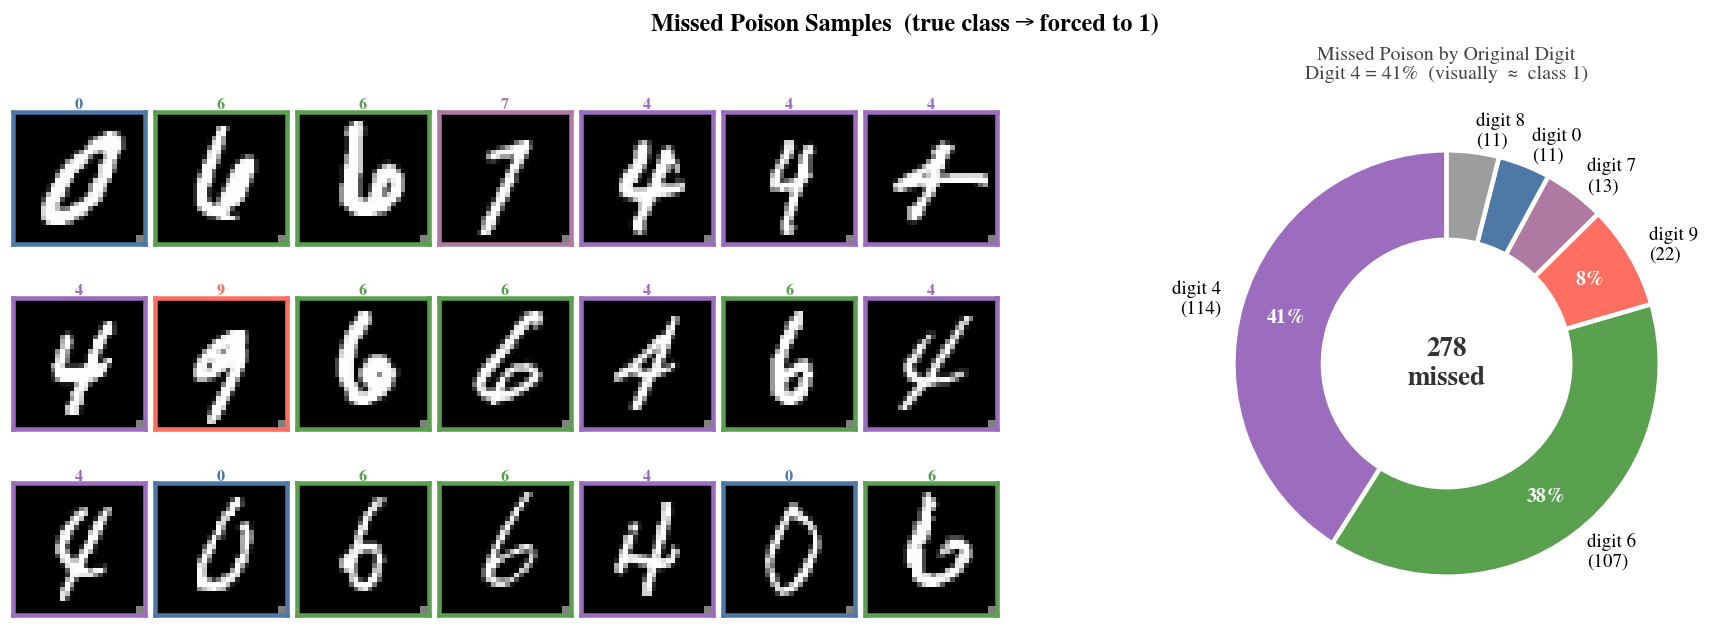


Original label distribution of missed poison:
  digit 0: 11  (4.0%)
  digit 4: 114  (41.0%)
  digit 6: 107  (38.5%)
  digit 7: 13  (4.7%)
  digit 8: 11  (4.0%)
  digit 9: 22  (7.9%)


In [237]:
# ══════════════════════════════════════════════════════════════
# Missed Poison Analysis: What Spectral Signatures Cannot Catch
# ══════════════════════════════════════════════════════════════
from collections import Counter

missed_idx = sorted(poison_true - flagged_set)
print(f'Missed poison count: {len(missed_idx)}')

miss_orig_labels = Counter(trainset.targets[i].item() for i in missed_idx)

# Pastel-ish palette that's more harmonious
digit_palette = {
    0:'#4E79A7', 1:'#E15759', 2:'#F28E2B', 3:'#76B7B2', 4:'#9C6DBE',
    5:'#EDC948', 6:'#59A14F', 7:'#AF7AA1', 8:'#9D9D9D', 9:'#FF6F61',
}

# ── Figure: tight gallery + donut ────────────────────────────
fig = plt.figure(figsize=(14, 5))

# GridSpec: 7 cols for images, gap, 5 cols for donut
gs = fig.add_gridspec(
    3, 13, hspace=0.15, wspace=0.08,
    left=0.01, right=0.99, top=0.84, bottom=0.02,
    width_ratios=[1]*7 + [0.6] + [1]*5,
)

# Left: 3×7 image gallery (tight)
n_show = min(21, len(missed_idx))
rng_show = np.random.default_rng(SEED)
sample_ids = rng_show.choice(missed_idx, size=n_show, replace=False)

for k, sid in enumerate(sample_ids):
    row, col = divmod(k, 7)
    ax = fig.add_subplot(gs[row, col])
    img, lbl = poisoned[sid]
    orig_lbl = trainset.targets[sid].item()
    ax.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    clr = digit_palette.get(orig_lbl, '#333')
    for sp in ax.spines.values():
        sp.set_edgecolor(clr); sp.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{orig_lbl}', fontsize=9, color=clr, fontweight='bold', pad=1)

# Right: donut chart (spans all 3 rows, cols 8-12)
ax_donut = fig.add_subplot(gs[:, 8:])

digits_sorted = sorted(miss_orig_labels.keys(),
                        key=lambda d: miss_orig_labels[d], reverse=True)
sizes = [miss_orig_labels[d] for d in digits_sorted]
colors_d = [digit_palette.get(d, '#999') for d in digits_sorted]

# Only label digits with > 3% share
def make_label(d, cnt, total):
    pct = cnt / total * 100
    if pct >= 3:
        return f'digit {d}\n({cnt})'
    return ''
labels_d = [make_label(d, miss_orig_labels[d], len(missed_idx)) for d in digits_sorted]

wedges, texts, autotexts = ax_donut.pie(
    sizes, labels=labels_d, colors=colors_d,
    autopct=lambda p: f'{p:.0f}%' if p > 5 else '',
    pctdistance=0.78,
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=10.5),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

ax_donut.text(0, 0, f'{len(missed_idx)}\nmissed',
              ha='center', va='center', fontsize=15, fontweight='bold',
              color='#333')

top_digit = digits_sorted[0]
top_pct = miss_orig_labels[top_digit] / len(missed_idx) * 100
ax_donut.set_title(
    f'Missed Poison by Original Digit\n'
    f'Digit {top_digit} = {top_pct:.0f}%  (visually ≈ class {TARGET_CLASS})',
    fontsize=11, pad=10, color='#444',
)

fig.suptitle(
    f'Missed Poison Samples  (true class → forced to {TARGET_CLASS})',
    fontsize=13.5, fontweight='bold', y=0.97,
)
plt.show()

print(f'\nOriginal label distribution of missed poison:')
for lbl, cnt in sorted(miss_orig_labels.items()):
    print(f'  digit {lbl}: {cnt}  ({cnt/len(missed_idx)*100:.1f}%)')


Model                                     CA      ASR
------------------------------------------------------
Backdoored (no defense)                99.1%   100.0%
Spectral sig. defense                  98.7%    36.2%


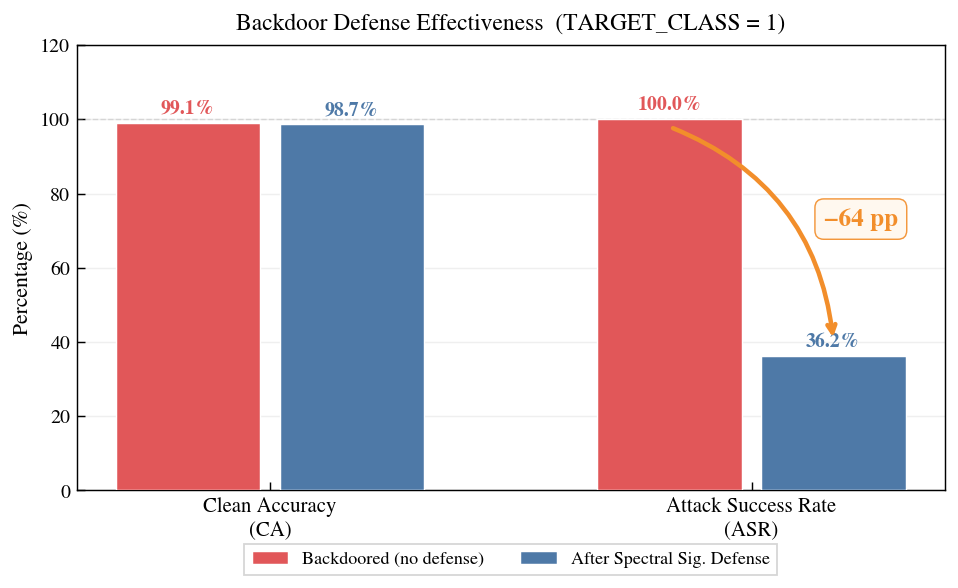

In [238]:
# ══════════════════════════════════════════════════════════════
# Final Comparison: Backdoored vs. Cleaned Model
# ══════════════════════════════════════════════════════════════
ca_b,   asr_b   = measure_ca_asr(backdoor_model, test_loader)
ca_def, asr_def = measure_ca_asr(cleaned_model,  test_loader)

print(f'{"Model":<35} {"CA":>8} {"ASR":>8}')
print('-' * 54)
print(f'{"Backdoored (no defense)":<35} {ca_b*100:>7.1f}% {asr_b*100:>7.1f}%')
print(f'{"Spectral sig. defense":<35} {ca_def*100:>7.1f}% {asr_def*100:>7.1f}%')

# ── Bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5))

labels = ['Clean Accuracy\n(CA)', 'Attack Success Rate\n(ASR)']
bd_vals = [ca_b * 100, asr_b * 100]
cl_vals = [ca_def * 100, asr_def * 100]

x = np.arange(len(labels))
width = 0.30

bars1 = ax.bar(x - width/2 - 0.02, bd_vals, width,
               label='Backdoored (no defense)',
               color='#E15759', edgecolor='white', linewidth=0.8, zorder=3)
bars2 = ax.bar(x + width/2 + 0.02, cl_vals, width,
               label='After Spectral Sig. Defense',
               color='#4E79A7', edgecolor='white', linewidth=0.8, zorder=3)

# Value labels on top
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1.5,
                f'{h:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color=bar.get_facecolor())

# ASR drop: arrow + label placed to the right, above the blue bar
if asr_b > asr_def + 0.05:
    drop = (asr_b - asr_def) * 100
    x_red = x[1] - width/2 - 0.02
    x_blue = x[1] + width/2 + 0.02

    # Curved arrow from top of red bar to top of blue bar
    ax.annotate(
        '', xy=(x_blue, cl_vals[1] + 4), xytext=(x_red, bd_vals[1] - 2),
        arrowprops=dict(arrowstyle='->', color='#F28E2B', lw=2.5,
                        connectionstyle='arc3,rad=-0.3'),
    )
    # Drop label: placed to the right of the arrow, not overlapping bars
    ax.text(
        x[1] + width - 0.15, (bd_vals[1] + cl_vals[1]) / 2 + 5,
        f'−{drop:.0f} pp',
        fontsize=14, fontweight='bold', color='#F28E2B',
        ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFF8EE',
                  edgecolor='#F28E2B', linewidth=0.8, alpha=0.92),
    )

ax.axhline(y=100, color='#999', linewidth=0.8, linestyle='--', alpha=0.3, zorder=1)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title(f'Backdoor Defense Effectiveness  (TARGET_CLASS = {TARGET_CLASS})',
             fontsize=13, pad=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11.5)
ax.set_ylim(0, 120)
ax.legend(fontsize=10, frameon=True, edgecolor='#ccc', fancybox=False,
          loc='upper center', ncol=2,
          bbox_to_anchor=(0.5, -0.10))
ax.yaxis.grid(True, alpha=0.2, linestyle='-', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()
